# OPX bench demo

Drive the OPX program builder (`kexp.control.opx`) interactively, without an experiment: build the QUA program for a sequence from `kexp/experiments/opx_sequences/`, simulate it on the QOP, and inspect the result.

`OPXBench` stands in for a prepared experiment with **kexp defaults** — the real `ExptParams` and the real dds-frame defaults, so the compiled config is exactly what a run would use — but no ARTIQ, no liveOD, no run id, nothing saved.

**Needs:** the root workspace venv as the kernel, and the OPX reachable on the lab network (the simulator runs on the QOP server, 192.168.1.125).

In [17]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
%load_ext autoreload
%autoreload 2

plt.rcParams['figure.dpi'] = 200

from kexp.control.opx import OPXBench
from kexp.experiments.opx_sequences.rabi import rabi_raman_pulse, rabi_raman_apd

bench = OPXBench()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Simulate one shot of a sequence

Declare xvars exactly as in an experiment's `prepare()`. On the bench, values run **in the order given** (no shuffle, no repeats), so simulated shot $k$ is `values[k]`, deterministically.

`simulate(...)` builds the per-shot tables, traces the program, sends it to the QOP simulator and **opens the pulse viewer** — a separate window (it never blocks the notebook) with every simulated pulse linked to the line of sequence code that made it. `shots=1` (default) simulates just the first scheduled shot — every scanned param bakes to that shot's value; `shots=0` simulates the whole scan. `duration` is the simulated OPX timeline in seconds; if it is shorter than the program the viewer says so (red hatch, diagnostics badge) rather than showing a silently cut sequence.

`viewer=False` skips the window and pops QM's own waveform report instead (`web_plot=True` forces that report even with the viewer on).

In [18]:
bench.xvar('t_raman_pulse', [15.e-6])

job = bench.simulate(rabi_raman_pulse, shots=1, duration=30.e-6, web_plot=False)

2026-09-24 01:13:32,487 - qm - INFO     - Performing health check
2026-09-24 01:13:32,490 - qm - INFO     - Health check passed
[opx] simulating the first 1 of 1 scheduled shot(s) (triggers skipped -- shots run back-to-back on the simulated timeline).
2026-09-24 01:13:32,551 - qm - INFO     - Simulating program
[opx] pulse viewer: 16 pulses, 0 events, 1 error-level warning(s) -> C:\Users\JARJAR~1\AppData\Local\Temp\waxx-seqview\20260924-011336-rabi_raman_pulse.npz
[opx] simulation complete; samples/report on self.sim_job.


## The pulse viewer

Top to bottom: an **overview** strip of the whole simulation with the current view as a draggable region; a **shots** header (shot index and that shot's scanned parameter values); **sequence steps** — one bar per macro call (`raman_pulse`, `wait_s`, `measure`, …; grey hatched bars are the framework's handoff / hand-back framing); **light ON** lanes per beam (a bar means the RF switch passes: light on the atoms); **ADC acquire** windows; the **hand-back** trigger. Press **P** for the physical port lanes underneath (D1–D4 as level traces labelled `BLOCK`/`pass`, A1/A2 as the sticky drive envelopes with phase-reset / frequency-change markers).

- **hover** a bar: start, end, length, requested vs actual (4 ns grid rounding is flagged), the `ctx.` macro, the parameter expression and its value on that shot, the source line, the QUA line.
- **click** a bar: the code pane scrolls to and highlights the line that made it; every other pulse dims and pulses from the same line get a dotted outline. **Click a line** in the code pane: every pulse it produced lights up. Double-click either to zoom there.
- **measure**: Shift+drag a span (cursors snap to edges; hold Alt to disable), or press **A** / **B** with the mouse over a point. Δ and 1/Δ sit in the status bar; Ctrl+C copies the readout. Gaps between consecutive bars on a lane are dimensioned automatically once they are wide enough on screen.
- **navigate**: wheel = zoom about the cursor, drag = pan, right-drag = box zoom, right-click = zoom out, `Home` fits the current shot, `F` fits all, `,` `.` step shots, `[` `]` jump edges, `0–9` jump to a shot. **Help → Keys and mouse** lists everything.
- **origin** combo: times relative to the shot start (default), absolute, or cursor A.
- **View → pulses**: a sortable, filterable table of every pulse (click a row to go there). **diagnostics** lists what the program asked for that the simulator did not report, and vice versa — the bars are always what the simulator returned, never what the program intended.

Re-running `bench.simulate(...)` (or an experiment with `simulate=True`) updates the open window in place, keeping zoom, lane layout and selection. `bench.view()` re-opens it after closing; `bench.viewer_bundle` is the data behind it.

## Inspect the traces yourself

The waveform report already plotted above. The raw simulated samples are on the job for manual plotting — digital 1 is the raman switch (high = ARTIQ RF blocked), digital 2 the imaging switch, digital 3 the hand-back trigger, analog 1/2 the sticky 80/150 MHz raman drives.

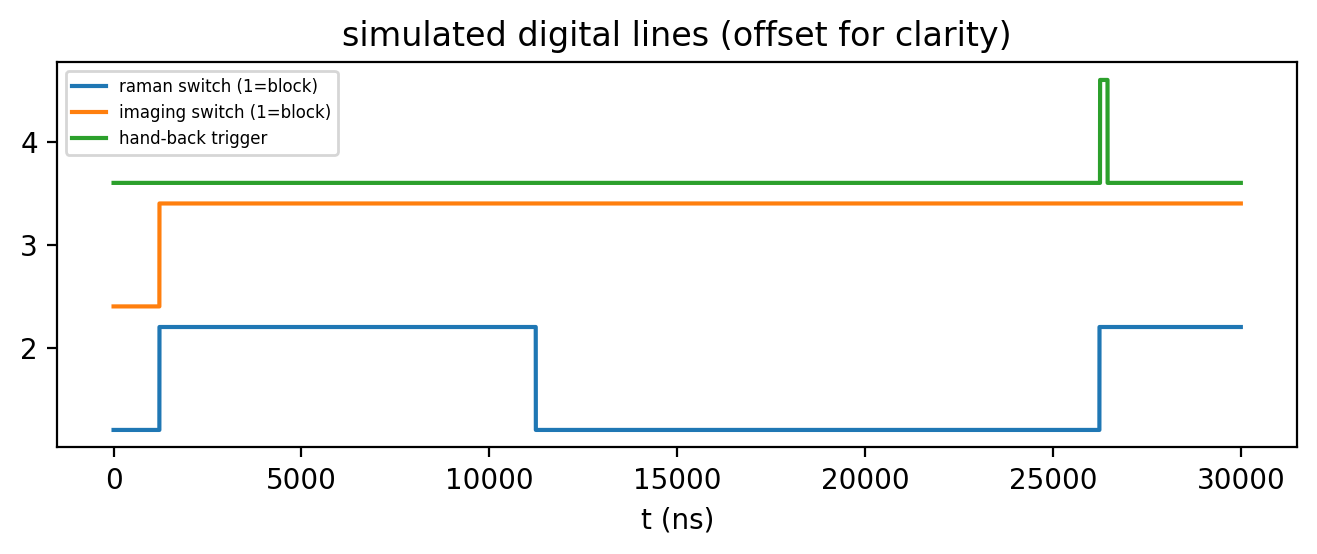

In [7]:
samples = job.get_simulated_samples()
# or by hand, e.g. the two switch lines and the hand-back trigger
fig, ax = plt.subplots(figsize=(8, 2.5))
for port, label in [('1', 'raman switch (1=block)'),
                    ('2', 'imaging switch (1=block)'),
                    ('3', 'hand-back trigger')]:
    d = samples.con1.digital[port]
    ax.plot(np.asarray(d, dtype=float) + 1.2 * float(port), label=label)
ax.set_xlabel('t (ns)')
ax.legend(fontsize=6)
ax.set_title('simulated digital lines (offset for clarity)');

## The generated program

`bench.qua_source` is the **real, triggered** program text — exactly what a run saves into the HDF5 as `opx_qua_program` (the simulation itself runs a variant with `wait_for_trigger` skipped, since the simulator has no trigger source).

In [8]:
print(bench.qua_source[:2000])


# Single QUA script generated at 2026-09-24 00:46:53.270299
# QUA library version: 1.4.1


from qm import CompilerOptionArguments
from qm.qua import *

with program() as prog:
    v1 = declare(int, )
    play('cw', 'raman_80')
    play('cw', 'raman_150')
    with for_(v1,0,(v1<1),(v1+1)):
        wait_for_trigger('raman_switch')
        align()
        play('block', 'raman_switch')
        play('block', 'imaging_switch')
        align()
        wait(2500, 'raman_switch')
        align()
        play('pass', 'raman_switch', duration=3750)
        play('block', 'raman_switch')
        align()
        play('trigger', 'artiq_handback')
        wait(7500, 'raman_switch', 'imaging_switch')
        play('pass', 'raman_switch')
        play('pass', 'imaging_switch')
        align()
    ramp_to_zero('raman_80', 0)
    ramp_to_zero('raman_150', 0)
    align()

config = {
    "controllers": {
        "con1": {
            "type": "opx1",
            "analog_outputs": {
                "1": {
   

## Tweak params and re-run

Every `simulate()` starts fresh (new manager, new DataVault), so iterate freely: edit a sequence file (autoreload picks it up), change `bench.p.<param>`, re-run the cell. A sequence with `measurements={...}` works the same — the APD acquire windows show up on the ADC marker (digital 4); its DataVault containers exist on the bench but nothing is fetched or saved.

2026-09-24 00:47:27,595 - qm - INFO     - Performing health check
2026-09-24 00:47:27,606 - qm - INFO     - Health check passed
[opx] simulating the first 1 of 1 scheduled shot(s) (triggers skipped -- shots run back-to-back on the simulated timeline).
2026-09-24 00:47:27,717 - qm - INFO     - Simulating program


c:\Users\jarjarbinks\code\.venv\Lib\site-packages\qm\program\_qua_config_schema.py:261: RemovedInMarshmallow4Warning: The `context` parameter is deprecated and will be removed in marshmallow 4.0. Use `contextvars.ContextVar` to pass context instead.
  QuaConfigSchema(


[opx] simulation complete; samples/report on self.sim_job.


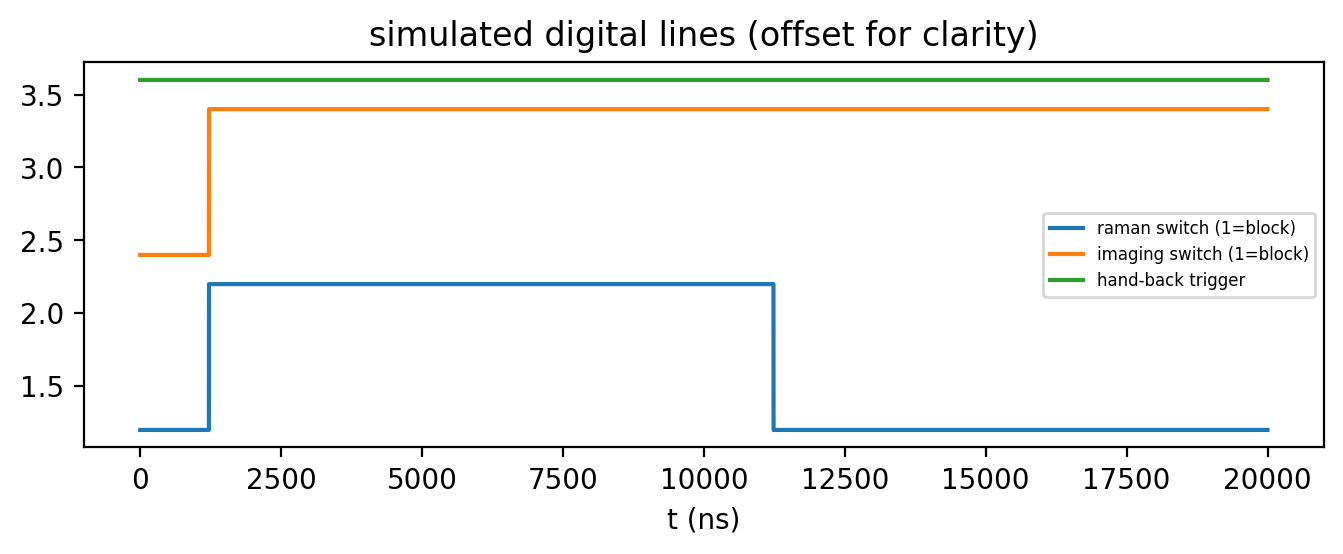

In [10]:
bench.p.t_raman_pi_pulse = 8.8e-6
job = bench.simulate(rabi_raman_apd, shots=1, duration=20.e-6, web_plot=False)
samples = job.get_simulated_samples()
# or by hand, e.g. the two switch lines and the hand-back trigger
fig, ax = plt.subplots(figsize=(8, 2.5))
for port, label in [('1', 'raman switch (1=block)'),
                    ('2', 'imaging switch (1=block)'),
                    ('3', 'hand-back trigger')]:
    d = samples.con1.digital[port]
    ax.plot(np.asarray(d, dtype=float) + 1.2 * float(port), label=label)
ax.set_xlabel('t (ns)')
ax.legend(fontsize=6)
ax.set_title('simulated digital lines (offset for clarity)');

## Define a sequence on the fly

`@opx_sequence` in a notebook cell gives the same object you would import — hand it straight to the bench (or to `self.opx.use(...)` in an experiment). Anything worth keeping should graduate into `kexp/experiments/opx_sequences/`.

In [ ]:
from kexp.control.opx import opx_sequence, OPXShotContext

@opx_sequence('two_pulse_demo', claims=('raman',))
def two_pulse_demo(ctx: OPXShotContext):
    """Two Raman exposures separated by a fixed dark time."""
    ctx.raman_pulse(ctx.p.t_raman_pulse)
    ctx.wait_s(5.e-6)
    ctx.raman_pulse(ctx.p.t_raman_pulse)

job = bench.simulate(two_pulse_demo, shots=1, duration=80.e-6)

2026-09-24 00:47:36,072 - qm - INFO     - Performing health check
2026-09-24 00:47:36,083 - qm - INFO     - Health check passed
[opx] simulating the first 1 of 1 scheduled shot(s) (triggers skipped -- shots run back-to-back on the simulated timeline).
2026-09-24 00:47:36,144 - qm - INFO     - Simulating program
[opx] simulation complete; samples/report on self.sim_job.


## In a real experiment

The bench and a run share all machinery; an experiment just swaps the bench for `Base`:

```python
self.opx.use(rabi_raman_pulse)                  # in prepare(), before finish_prepare()
self.finish_prepare(shuffle=True)               # compiles + starts the job
# scan_kernel: prep_raman() -> handoff_to_quantum_machines() -> wait_for_quantum_machines_handoff()
```

Working examples live next to this notebook: `qm_rabi_frequency_opx.py` (camera readout) and `check_rabi_frequency_apd_opx.py` (integrated APD readout). Remember `prep_raman()` before the handoff — the switch-AOM warm-up (shutter closed) is ARTIQ's job, not the OPX's.